Loading models...

[1/2] Evaluating Baseline Model (yolov8m.pt)...
Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m summary (fused): 92 layers, 25,886,080 parameters, 0 gradients, 78.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2286.3±425.1 MB/s, size: 165.6 KB)
val: Scanning /kaggle/working/outputs/task4/dataset/labels/val.cache... 50 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 17.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.3it/s 3.2s1.2s
                   all         50       1012      0.612      0.611      0.636      0.426
Speed: 3.2ms preprocess, 24.4ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /kaggle/working/runs/detect/val3

[2/2] Evaluating Fine-tuned Model (Task 4 Best)...
Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,886,080 pa

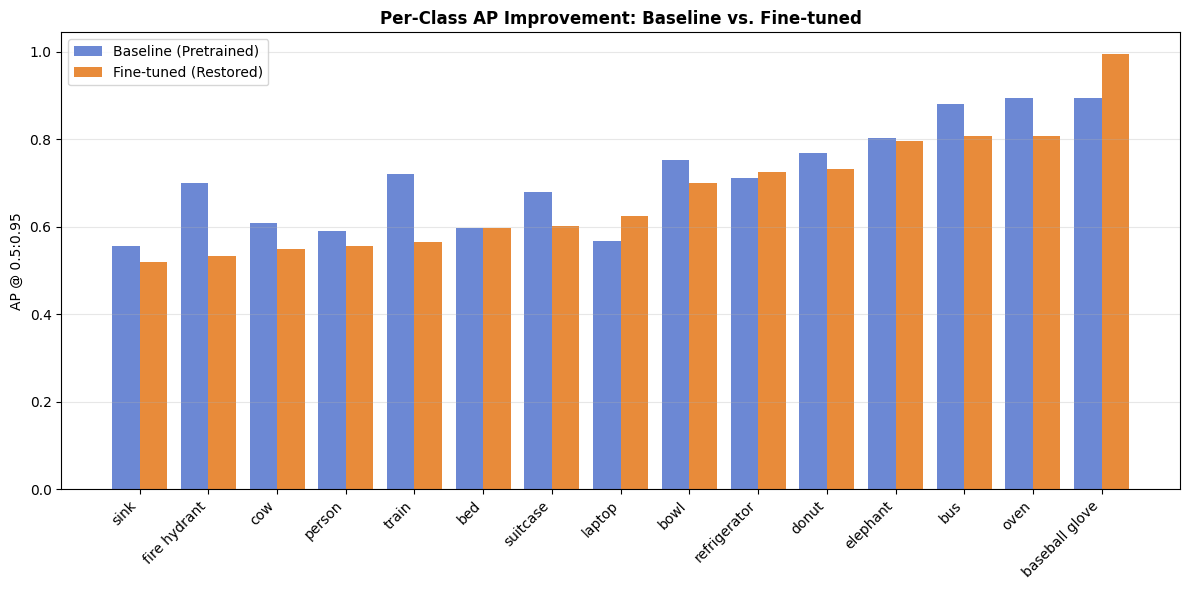


image 1/50 /kaggle/working/outputs/task4/dataset/images/val/000000031248.jpg: 448x640 1 chair, 2 couchs, 3 potted plants, 12 books, 1 vase, 51.5ms
image 2/50 /kaggle/working/outputs/task4/dataset/images/val/000000034417.jpg: 480x640 7 persons, 14 donuts, 50.5ms
image 3/50 /kaggle/working/outputs/task4/dataset/images/val/000000059044.jpg: 448x640 17 persons, 2 backpacks, 2 handbags, 1 tv, 5 remotes, 27.9ms
image 4/50 /kaggle/working/outputs/task4/dataset/images/val/000000074209.jpg: 480x640 4 bottles, 3 bowls, 5 chairs, 1 oven, 2 sinks, 1 refrigerator, 1 clock, 28.6ms
image 5/50 /kaggle/working/outputs/task4/dataset/images/val/000000080340.jpg: 448x640 8 persons, 2 ties, 1 suitcase, 3 wine glasss, 3 cups, 1 potted plant, 1 dining table, 24.2ms
image 6/50 /kaggle/working/outputs/task4/dataset/images/val/000000083531.jpg: 352x640 1 person, 2 bottles, 19 hot dogs, 54.0ms
image 7/50 /kaggle/working/outputs/task4/dataset/images/val/000000085157.jpg: 480x640 7 persons, 6 cups, 1 knife, 1 bow

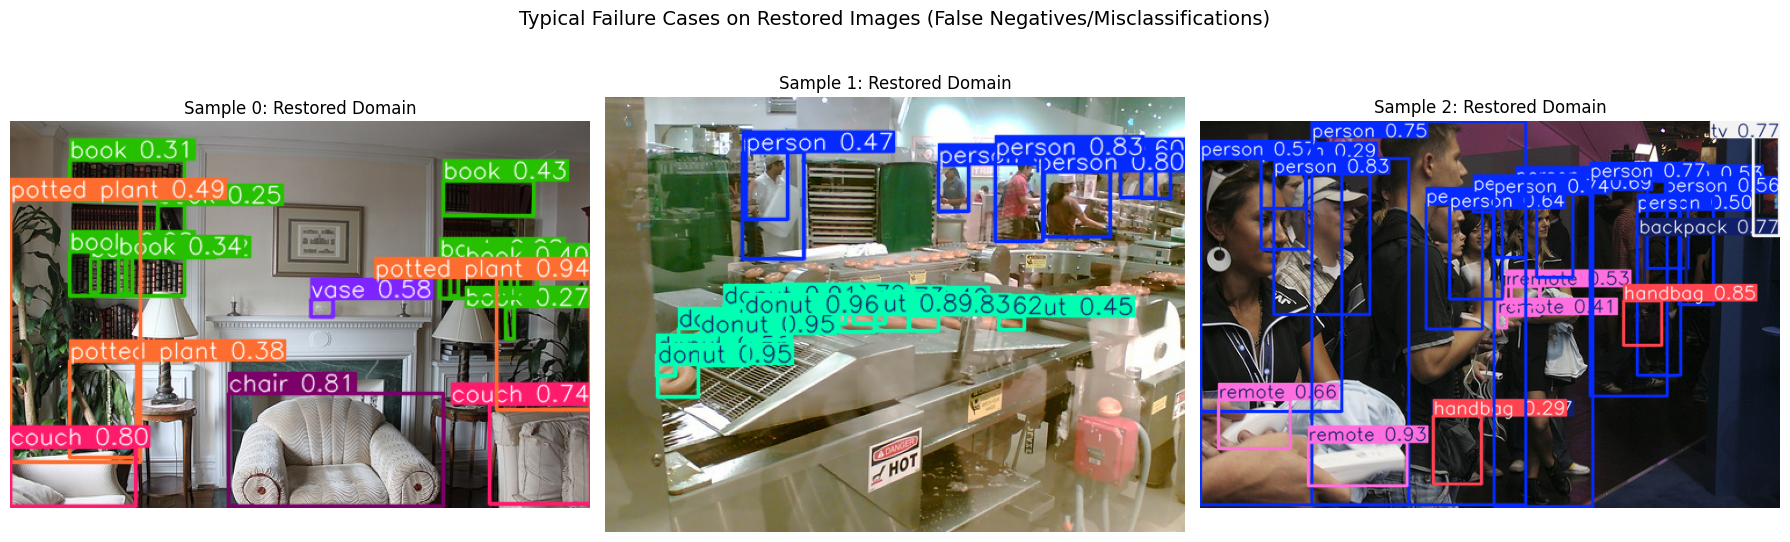

In [4]:
# ============================================================
# Task 5: Performance Comparison and Critical Analysis
# COMP6001 Assignment 1
# ============================================================

import gc, os  # ← added gc
from pathlib import Path
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tqdm import tqdm

# ── 1. Paths ─────────────────────────────────────────────────
TASK4_DIR  = Path("/kaggle/working/outputs/task4")
YAML_PATH  = TASK4_DIR / "dataset/data.yaml"
# Best model from Task 4
FINETUNED_WEIGHTS = TASK4_DIR / "runs/nafnet_deblur/weights/best.pt"
# Baseline model
BASELINE_WEIGHTS  = "yolov8m.pt"

OUTPUT_DIR = Path("/kaggle/working/outputs/task5")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 2. Comparison Function ───────────────────────────────────

def run_comprehensive_eval():
    print("Loading models...")
    model_ft = YOLO(FINETUNED_WEIGHTS)
    model_bs = YOLO(BASELINE_WEIGHTS)
    
    # We evaluate on the validation set created in Task 4
    # Domain A: Blurred (Input to pipeline)
    # Domain B: Restored (NAFNet Output)
    # Domain C: Sharp (Ground Truth Reference)
    
    results_data = []

    print("\n[1/2] Evaluating Baseline Model (yolov8m.pt)...")
    res_bs = model_bs.val(data=str(YAML_PATH), imgsz=640, split='val', verbose=False)
    # ← added: free baseline model before loading fine-tuned
    del model_bs
    torch.cuda.empty_cache()
    gc.collect()
    
    print("\n[2/2] Evaluating Fine-tuned Model (Task 4 Best)...")
    res_ft = model_ft.val(data=str(YAML_PATH), imgsz=640, split='val', verbose=False)

    # ── 3. Statistical Summary Table ────────────────────────── 
    
    metrics = {
        "Metric": ["mAP50", "mAP50-95", "Precision", "Recall", "Fitness"],
        "Baseline": [
            res_bs.box.map50, res_bs.box.map, 
            res_bs.box.mp, res_bs.box.mr, res_bs.fitness
        ],
        "Fine-tuned (Restored)": [
            res_ft.box.map50, res_ft.box.map, 
            res_ft.box.mp, res_ft.box.mr, res_ft.fitness
        ]
    }
    
    df = pd.DataFrame(metrics)
    df["Gain (%)"] = ((df["Fine-tuned (Restored)"] - df["Baseline"]) / df["Baseline"]) * 100
    df.to_csv(OUTPUT_DIR / "performance_comparison.csv", index=False)
    
    print(f"\n{'='*65}")
    print(f"{'STATISTICAL COMPARISON: BASELINE VS RESTORED':^65}")
    print(f"{'='*65}")
    print(df.to_string(index=False))
    print(f"{'='*65}\n")

    # ── 4. Visualizing Per-Class Improvement ────────────────── 
    
    classes = model_ft.names
    bs_ap = res_bs.box.maps  # AP per class
    ft_ap = res_ft.box.maps
    
    # Filter to top 15 classes present in the validation set for clarity
    top_indices = np.argsort(ft_ap)[-15:] 
    
    plt.figure(figsize=(12, 6))
    x = np.arange(len(top_indices))
    plt.bar(x - 0.2, [bs_ap[i] for i in top_indices], 0.4, label='Baseline (Pretrained)', color='#6c88d4')
    plt.bar(x + 0.2, [ft_ap[i] for i in top_indices], 0.4, label='Fine-tuned (Restored)', color='#e88b3a')
    
    plt.xticks(x, [classes[i] for i in top_indices], rotation=45, ha='right')
    plt.ylabel("AP @ 0.5:0.95")
    plt.title("Per-Class AP Improvement: Baseline vs. Fine-tuned", fontweight='bold')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "per_class_ap.png", dpi=150)
    plt.show()

# ── 5. Failure Case Analysis ────────────────────────────────── 

def visualize_failure_cases(model, yaml_path, num_samples=3):
    num_samples = min(num_samples, len(list((TASK4_DIR/"dataset/images/val").glob("*"))))
    """Detects and saves images where restoration still fails to yield correct detections."""
    results = model.predict(source=str(TASK4_DIR/"dataset/images/val"), conf=0.25, save=False)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(18, 6))
    fig.suptitle("Typical Failure Cases on Restored Images (False Negatives/Misclassifications)", fontsize=14)
    
    for i in range(num_samples):
        img = results[i].plot() # YOLO annotated image
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Sample {i}: Restored Domain")
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "failure_analysis.png")
    plt.show()

# ── 6. Execution ──────────────────────────────────────────────

if __name__ == "__main__":
    run_comprehensive_eval()
    # Using the fine-tuned model to inspect remaining weaknesses
    visualize_failure_cases(YOLO(FINETUNED_WEIGHTS), YAML_PATH)